### KNN Model Regression

In [1]:
# impprt requrie libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
# Lode the dataset
df = pd.read_csv("Datasets\\knn_regression_dataset.csv")

In [3]:
# Display the frist few rows on Dataset
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [4]:
# Check the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [5]:
# Statistical summery of the dataset
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


In [6]:
# Check the missing values
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [7]:
# Frist handdle the missing value with median
df["income"] = df["income"].fillna(df["income"].median(),inplace=True)

# handled credit card with median
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].median(),inplace=True)
 
# Handled loan missing value with median
df["loan_amount"] = df["loan_amount"].fillna(df["loan_amount"].median(),inplace=True)


C:\Users\lonka\AppData\Local\Temp\ipykernel_26808\3759625160.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income"] = df["income"].fillna(df["income"].median(),inplace=True)
C:\Users\lonka\AppData\Local\Temp\ipykernel_26808\3759625160.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [8]:
# Check the missing value
df.isnull().sum()

age                   0
income             1000
loan_amount        1000
credit_score       1000
city                  0
employment_type       0
target                0
dtype: int64

In [9]:
#check the credit Score
df["credit_score"] 

0      None
1      None
2      None
3      None
4      None
       ... 
995    None
996    None
997    None
998    None
999    None
Name: credit_score, Length: 1000, dtype: object

#use round for credit score and income 2 decimal place
df["credit_score"] =df["credit_score"].round(2)
df["income"] =df["income"].round(2)
df["loan_amount"] =df["loan_amount"].round(2)

In [10]:
# Round values
df["credit_score"] = df["credit_score"]
df["income"] = df["income"]
df["loan_amount"] = df["loan_amount"]

In [11]:
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,None,None,None,Chennai,Salaried,158793.631698
1,69,None,None,None,Chennai,Salaried,115596.093965
2,46,None,None,None,Chennai,Salaried,127231.057638
3,32,None,None,None,Chennai,Unemployed,145102.187078
4,60,None,None,None,Hyderabad,Unemployed,110623.128404


<Axes: >

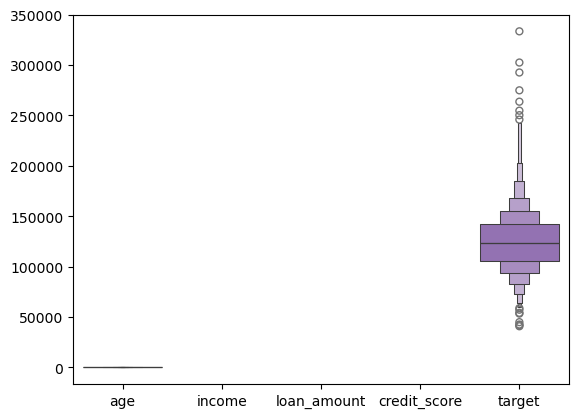

In [12]:
# Display the boxplot for each feture to check outliers
plt.Figure(figsize=(15,10))

sns.boxenplot(data=df)

In [13]:
abnormal_col=["income","loan_amount","credit_score"]

for col in abnormal_col:
     Q1=df[col].quantile(0.25)
     Q3=df[col].quantile(0.75)
     IQR=Q3-Q1
     lower_bound=Q1-1.5*IQR
     upper_bound=Q3+1.5*IQR
     df[col]=df[col].clip(
         lower=lower_bound,
         upper=upper_bound
     )
print(df.head)

<bound method NDFrame.head of      age income loan_amount credit_score       city employment_type  \
0     56   None        None         None    Chennai        Salaried   
1     69   None        None         None    Chennai        Salaried   
2     46   None        None         None    Chennai        Salaried   
3     32   None        None         None    Chennai      Unemployed   
4     60   None        None         None  Hyderabad      Unemployed   
..   ...    ...         ...          ...        ...             ...   
995   60   None        None         None    Chennai        Salaried   
996   64   None        None         None  Bangalore   Self-Employed   
997   62   None        None         None  Hyderabad      Unemployed   
998   35   None        None         None  Bangalore      Unemployed   
999   55   None        None         None    Chennai        Salaried   

            target  
0    158793.631698  
1    115596.093965  
2    127231.057638  
3    145102.187078  
4    110623.

<Axes: >

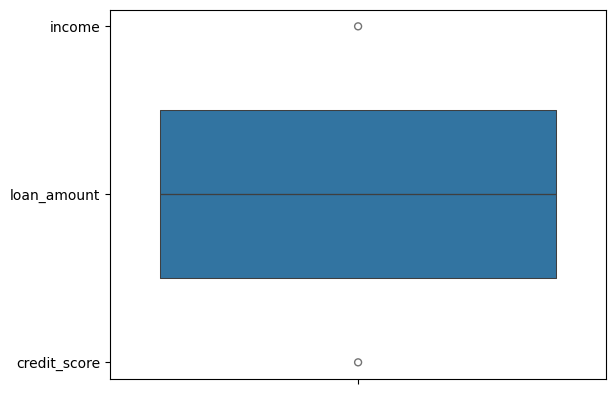

In [14]:
# make boxplot again to check outliers
sns.boxenplot(data=abnormal_col)

In [15]:
# check the value count in the city column

df["city"].value_counts()

city
Hyderabad    260
Chennai      259
Bangalore    256
Mumbai       225
Name: count, dtype: int64

In [16]:
# check the value for employeement_type
df["employment_type"].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [17]:
# handle the categorical data with one hot encoding

from sklearn.preprocessing import OneHotEncoder

categorical_columns=['city','employment_type']
#create an instance of one hot encoder
encoder = OneHotEncoder(sparse_output=False)
#Fit tranform the encoderon the categorical columns
encoded_data = encoder.fit_transform(df[categorical_columns])


In [18]:
#convert the encoded data to DataFrame
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(categorical_columns))

# concatenate the encoded DataFrame with orignal DataFrame
df=pd.concat([df,encoded_df],axis=1)

In [19]:
df.drop(columns=categorical_columns, inplace=True)

In [20]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,None,None,None,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,None,None,None,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,None,None,None,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,None,None,None,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,None,None,None,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [21]:
# Divide into features and target variable
x=df.drop(columns=['target'])
y=df['target']

In [22]:
# split dataset into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
print(x_train.isnull().sum())
print(x_test.isnull().sum())

age                                0
income                           800
loan_amount                      800
credit_score                     800
city_Bangalore                     0
city_Chennai                       0
city_Hyderabad                     0
city_Mumbai                        0
employment_type_Salaried           0
employment_type_Self-Employed      0
employment_type_Unemployed         0
dtype: int64
age                                0
income                           200
loan_amount                      200
credit_score                     200
city_Bangalore                     0
city_Chennai                       0
city_Hyderabad                     0
city_Mumbai                        0
employment_type_Salaried           0
employment_type_Self-Employed      0
employment_type_Unemployed         0
dtype: int64


In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Create median imputer
imputer = SimpleImputer(strategy="median")

# Fit imputer only on training data
x_train_imputed = imputer.fit_transform(x_train)

# Apply same imputer to test data
x_test_imputed = imputer.transform(x_test)

# Step 2: Scale the features
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_imputed)
x_test_scaled = scaler.transform(x_test_imputed)

# Step 3: Create KNN model
knn_model = KNeighborsRegressor(n_neighbors=7)

# Fit the model
knn_model.fit(x_train_scaled, y_train)

# Make predictions
knn_predictions = knn_model.predict(x_test_scaled)

# Step 4: Evaluate model
mse = mean_squared_error(y_test, knn_predictions)
r2 = r2_score(y_test, knn_predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 1209840325.52
R-squared Score: -0.1596


d:\Poonam\Anaconda\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['income' 'loan_amount' 'credit_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
d:\Poonam\Anaconda\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['income' 'loan_amount' 'credit_score']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


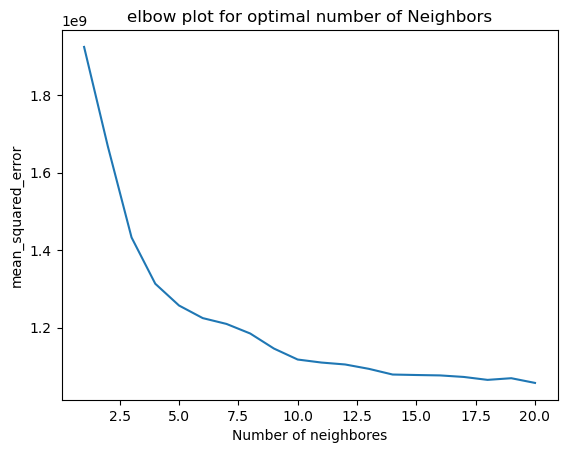

In [25]:
# Make the elow plot to find the optimal number of neighbours
mse_values =[] 
for k in range(1,21):
    knn_model=KNeighborsRegressor(n_neighbors=k)
    knn_model.fit(x_train_scaled,y_train)
    knn_predictions=knn_model.predict(x_test_scaled)
    mse=mean_squared_error(y_test,knn_predictions)
    mse_values.append(mse)

#plot the mean squard error values against the number of neighbors

import matplotlib.pyplot as plt

plt.plot(range(1,21),mse_values)
plt.xlabel('Number of neighbores')
plt.ylabel('mean_squared_error')
plt.title('elbow plot for optimal number of Neighbors')

plt.show()
    